# Julia is fast

Very often, benchmarks are used to compare languages.  These benchmarks can lead to long discussions, first as to exactly what is being benchmarked and secondly what explains the differences.  These simple questions can sometimes get more complicated than you at first might imagine.

The purpose of this notebook is for you to see a simple benchmark for yourself.  One can read the notebook and see what happened on the author's Macbook Pro with a 4-core Intel Core I7, or run the notebook yourself.

(This material began life as a wonderful lecture by Steven Johnson at MIT: https://github.com/stevengj/18S096/blob/master/lectures/lecture1/Boxes-and-registers.ipynb.)

# Outline of this notebook

- Define the sum function
- Implementations & benchmarking of sum in...
    - C (hand-written)
    - C (hand-written with -ffast-math)
    - python (built-in)
    - python (numpy)
    - python (hand-written)
    - Julia (built-in)
    - Julia (hand-written)
    - Julia (hand-written with SIMD)
- Summary of benchmarks

# `sum`: An easy enough function to understand

Consider the  **sum** function `sum(a)`, which computes
$$
\mathrm{sum}(a) = \sum_{i=1}^n a_i,
$$
where $n$ is the length of `a`.

In [1]:
a = rand(10^7) # 1D vector of random numbers, uniform on [0,1)

10000000-element Vector{Float64}:
 0.31950016873852205
 0.8500734477823586
 0.4360882857298948
 0.7567222351780197
 0.22423908855242625
 0.8903635678255962
 0.24007254199176842
 0.22443933534017835
 0.22068800259107157
 0.4537947200775784
 ⋮
 0.3661259299975975
 0.13914105725953085
 0.07711680643801122
 0.09784058006514718
 0.35431450855359914
 0.8194198876216404
 0.9710544649473447
 0.6102334584100931
 0.7152414901946499

In [2]:
sum(a)

4.999657746342255e6

The expected result is 0.5 * 10^7, since the mean of each entry is 0.5

# Benchmarking a few ways in a few languages

In [3]:
@time sum(a)

  0.006078 seconds (1 allocation: 16 bytes)


4.999657746342255e6

In [4]:
@time sum(a)

  0.004338 seconds (1 allocation: 16 bytes)


4.999657746342255e6

In [5]:
@time sum(a)

  0.003906 seconds (1 allocation: 16 bytes)


4.999657746342255e6

The `@time` macro can yield noisy results, so it's not our best choice for benchmarking!

Luckily, Julia has a `BenchmarkTools.jl` package to make benchmarking easy and accurate:

In [6]:
using Pkg
Pkg.add("BenchmarkTools")

    Updating registry at `C:\Users\yzdom\.julia\registries\General.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\yzdom\Projects\intro_to_julia_for_prog\Project.toml`
    Manifest No packages added to or removed from `C:\Users\yzdom\Projects\intro_to_julia_for_prog\Manifest.toml`


In [7]:
using BenchmarkTools  

#  1. The C language

C is often considered the gold standard: difficult on the human, nice for the machine. Getting within a factor of 2 of C is often satisfying. Nonetheless, even within C, there are many kinds of optimizations possible that a naive C writer may or may not get the advantage of.

The current author does not speak C, so he does not read the cell below, but is happy to know that you can put C code in a Julia session, compile it, and run it. Note that the `"""` wrap a multi-line string.

In [8]:
using Libdl
C_code = """
#include <stddef.h>
double c_sum(size_t n, double *X) {
    double s = 0.0;
    for (size_t i = 0; i < n; ++i) {
        s += X[i];
    }
    return s;
}
"""

const Clib = tempname()   # make a temporary file


# compile to a shared library by piping C_code to gcc
# (works only if you have gcc installed):

open(`gcc -fPIC -O3 -msse3 -xc -shared -o $(Clib * "." * Libdl.dlext) -`, "w") do f
    print(f, C_code) 
end

# define a Julia function that calls the C function:
c_sum(X::Array{Float64}) = ccall(("c_sum", Clib), Float64, (Csize_t, Ptr{Float64}), length(X), X)

Base.IOError: IOError: could not spawn `gcc -fPIC -O3 -msse3 -xc -shared -o 'C:\Users\yzdom\AppData\Local\Temp\jl_rATCNebira.dll' -`: no such file or directory (ENOENT)

In [9]:
c_sum(a)

5.000406093458116e6

In [10]:
c_sum(a) ≈ sum(a) # type \approx and then <TAB> to get the ≈ symbolb

true

In [11]:
c_sum(a) - sum(a)  

-3.818422555923462e-8

In [12]:
≈  # alias for the `isapprox` function

isapprox (generic function with 9 methods)

In [9]:
?isapprox

Base.Meta.ParseError: ParseError:
# Error @ c:\Users\yzdom\Projects\intro_to_julia_for_prog\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X26sZmlsZQ==.jl:1:1
?isapprox
╙ ── not a unary operator

We can now benchmark the C code directly from Julia:

In [14]:
c_bench = @benchmark c_sum($a)

BenchmarkTools.Trial: 526 samples with 1 evaluation.
 Range (min … max):  9.383 ms …  9.905 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     9.494 ms              ┊ GC (median):    0.00%
 Time  (mean ± σ):   9.499 ms ± 69.737 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

       ▁       ▁▄▅▆█▅▃                                        
  ▄▄▃▃▄█▆█▇▇▆▇████████▆▇▅▄▅▃▄▄▃▃▃▃▂▃▃▁▂▃▃▁▂▁▂▂▁▂▃▁▂▃▁▃▂▂▁▁▁▂ ▄
  9.38 ms        Histogram: frequency by time        9.78 ms <

 Memory estimate: 0 bytes, allocs estimate: 0.

In [10]:
c_bench = @benchmark sum($a)

BenchmarkTools.Trial: 1273 samples with 1 evaluation per sample.
 Range (min … max):  3.258 ms …   6.925 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     3.650 ms               ┊ GC (median):    0.00%
 Time  (mean ± σ):   3.901 ms ± 592.120 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

   ▄▁▁█▇▁▁                                                     
  ▄███████▇▇▆▄▄▅▃▄▅▃▃▃▃▃▃▄▂▄▂▃▃▃▂▄▃▃▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁ ▃
  3.26 ms         Histogram: frequency by time        5.67 ms <

 Memory estimate: 0 bytes, allocs estimate: 0.

In [15]:
println("C: Fastest time was $(minimum(c_bench.times) / 1e6) msec")

C: Fastest time was 9.382875 msec


In [11]:
d = Dict()  # a "dictionary", i.e. an associative array
d["C"] = minimum(c_bench.times) / 1e6  # in milliseconds
d

Dict{Any, Any} with 1 entry:
  "C" => 3.258

In [12]:
using Plots
gr()

Plots.GRBackend()

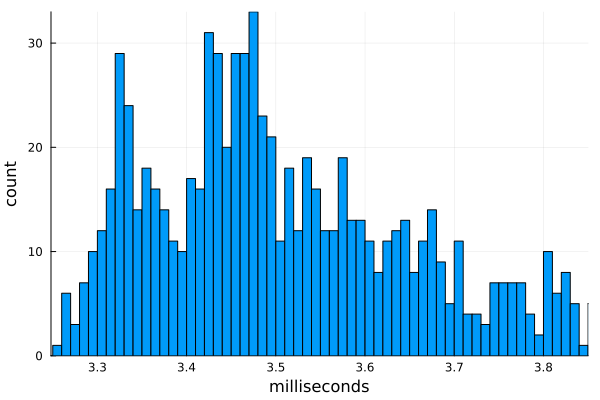

In [13]:
using Statistics # bring in statistical support for standard deviations
t = c_bench.times / 1e6 # times in milliseconds
m, σ = minimum(t), std(t)

histogram(t, bins=500,
    xlim=(m - 0.01, m + σ),
    xlabel="milliseconds", ylabel="count", label="")

# 2. C with -ffast-math

If we allow C to re-arrange the floating point operations, then it'll vectorize with SIMD (single instruction, multiple data) instructions.

In [19]:
const Clib_fastmath = tempname()   # make a temporary file

# The same as above but with a -ffast-math flag added
open(`gcc -fPIC -O3 -msse3 -xc -shared -ffast-math -o $(Clib_fastmath * "." * Libdl.dlext) -`, "w") do f
    print(f, C_code) 
end

# define a Julia function that calls the C function:
c_sum_fastmath(X::Array{Float64}) = ccall(("c_sum", Clib_fastmath), Float64, (Csize_t, Ptr{Float64}), length(X), X)

c_sum_fastmath (generic function with 1 method)

In [20]:
c_fastmath_bench = @benchmark $c_sum_fastmath($a)

BenchmarkTools.Trial: 2703 samples with 1 evaluation.
 Range (min … max):  1.781 ms …  3.144 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     1.806 ms              ┊ GC (median):    0.00%
 Time  (mean ± σ):   1.833 ms ± 86.937 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

  █▃                                                          
  ██▇▅▇▇▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▂▂▂▂▂▂▂▁▂▂▂▂▂▁▂ ▃
  1.78 ms        Histogram: frequency by time        2.23 ms <

 Memory estimate: 0 bytes, allocs estimate: 0.

In [21]:
d["C -ffast-math"] = minimum(c_fastmath_bench.times) / 1e6  # in milliseconds

1.781208

# 3. Python's built in `sum` 

The `PyCall` package provides a Julia interface to Python:

In [14]:
using Pkg; Pkg.add("PyCall")
using PyCall

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\yzdom\Projects\intro_to_julia_for_prog\Project.toml`
    Manifest No packages added to or removed from `C:\Users\yzdom\Projects\intro_to_julia_for_prog\Manifest.toml`


In [15]:
# get the Python built-in "sum" function:
pysum = pybuiltin("sum")

PyObject <built-in function sum>

In [16]:
pysum(a)

4.9996577463420015e6

In [17]:
pysum(a) ≈ sum(a)

true

In [18]:
py_list_bench = @benchmark $pysum($a)

BenchmarkTools.Trial: 11 samples with 1 evaluation per sample.
 Range (min … max):  471.293 ms … 493.075 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     479.372 ms               ┊ GC (median):    0.00%
 Time  (mean ± σ):   480.868 ms ±   5.932 ms  ┊ GC (mean ± σ):  0.00% ± 0.00%

  ▁      ▁         ▁   █▁          ▁ █   ▁                    ▁  
  █▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁█▁▁▁██▁▁▁▁▁▁▁▁▁▁█▁█▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█ ▁
  471 ms           Histogram: frequency by time          493 ms <

 Memory estimate: 208 bytes, allocs estimate: 8.

In [19]:
d["Python built-in"] = minimum(py_list_bench.times) / 1e6
d

Dict{Any, Any} with 2 entries:
  "C"               => 3.258
  "Python built-in" => 471.293

# 4. Python: `numpy` 

## Takes advantage of hardware "SIMD", but only works when it works.

`numpy` is an optimized C library, callable from Python.
It may be installed within Julia as follows:

In [20]:
using Pkg; Pkg.add("Conda")
using Conda

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\yzdom\Projects\intro_to_julia_for_prog\Project.toml`
    Manifest No packages added to or removed from `C:\Users\yzdom\Projects\intro_to_julia_for_prog\Manifest.toml`


In [21]:
Conda.add("numpy")

┌ Info: Running `conda install -y numpy` in root environment
└ @ Conda C:\Users\yzdom\.julia\packages\Conda\05AVg\src\Conda.jl:181


Channels:
 - conda-forge
Platform: win-64
Solving environment: done

# All requested packages already installed.





==> WARNING: A newer version of conda exists. <==
    current version: 26.1.0
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c conda-forge conda




In [22]:
numpy_sum = pyimport("numpy")["sum"]

py_numpy_bench = @benchmark $numpy_sum($a)

BenchmarkTools.Trial: 865 samples with 1 evaluation per sample.
 Range (min … max):  4.641 ms …  11.120 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     5.565 ms               ┊ GC (median):    0.00%
 Time  (mean ± σ):   5.754 ms ± 853.001 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

  ▁██▄▁      ▅▇▄▂▂          ▁                                  
  █████▇█▆▆▇▇█████▇█▇▆▆█▇▇▇▆█▇▇█▇▆▇▅▅▅▄▄▄▄▃▄▄▃▃▄▃▃▂▂▃▂▃▃▁▃▃▂▃ ▄
  4.64 ms         Histogram: frequency by time        8.19 ms <

 Memory estimate: 208 bytes, allocs estimate: 8.

In [23]:
numpy_sum(a)

4.999657746342256e6

In [24]:
numpy_sum(a) ≈ sum(a)

true

In [25]:
d["Python numpy"] = minimum(py_numpy_bench.times) / 1e6
d

Dict{Any, Any} with 3 entries:
  "C"               => 3.258
  "Python numpy"    => 4.6414
  "Python built-in" => 471.293

# 5. Python, hand-written 

In [26]:
py"""
def py_sum(A):
    s = 0.0
    for a in A:
        s += a
    return s
"""

sum_py = py"py_sum"

PyObject <function py_sum at 0x000001D355E1DB20>

In [27]:
py_hand = @benchmark $sum_py($a)

BenchmarkTools.Trial: 8 samples with 1 evaluation per sample.
 Range (min … max):  672.053 ms … 688.877 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     679.461 ms               ┊ GC (median):    0.00%
 Time  (mean ± σ):   679.170 ms ±   5.609 ms  ┊ GC (mean ± σ):  0.00% ± 0.00%

  █     █    █      █                ███                      █  
  █▁▁▁▁▁█▁▁▁▁█▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁███▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█ ▁
  672 ms           Histogram: frequency by time          689 ms <

 Memory estimate: 208 bytes, allocs estimate: 8.

In [37]:
sum_py(a)

5.000406093458116e6

In [38]:
sum_py(a) ≈ sum(a)

true

In [28]:
d["Python hand-written"] = minimum(py_hand.times) / 1e6
d

Dict{Any, Any} with 4 entries:
  "C"                   => 3.258
  "Python numpy"        => 4.6414
  "Python hand-written" => 672.053
  "Python built-in"     => 471.293

# 6. Julia (built-in) 

## Written directly in Julia, not in C!

In [29]:
@which sum(a)

sum(a::AbstractArray; dims, kw...)
     @ Base reducedim.jl:979

In [30]:
j_bench = @benchmark sum($a)

BenchmarkTools.Trial: 1230 samples with 1 evaluation per sample.
 Range (min … max):  3.251 ms …  14.510 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     3.811 ms               ┊ GC (median):    0.00%
 Time  (mean ± σ):   4.047 ms ± 825.106 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

   ▄▂█▃▁▂▂                                                     
  ▆███████▇▇▇▆▆▆▆▆▅▅▅▅▆▄▄▅▅▅▄▄▃▃▃▂▃▃▃▃▂▂▂▂▃▂▂▁▁▂▂▂▂▁▁▁▂▂▂▁▁▁▂ ▃
  3.25 ms         Histogram: frequency by time        6.92 ms <

 Memory estimate: 0 bytes, allocs estimate: 0.

In [31]:
d["Julia built-in"] = minimum(j_bench.times) / 1e6
d

Dict{Any, Any} with 5 entries:
  "C"                   => 3.258
  "Python numpy"        => 4.6414
  "Python hand-written" => 672.053
  "Python built-in"     => 471.293
  "Julia built-in"      => 3.2509

# 7. Julia (hand-written) 

In [32]:
function mysum(A)   
    s = 0.0 # s = zero(eltype(a))
    for a in A
        s += a
    end
    s
end

mysum (generic function with 1 method)

In [33]:
j_bench_hand = @benchmark mysum($a)

BenchmarkTools.Trial: 767 samples with 1 evaluation per sample.
 Range (min … max):  5.292 ms …   8.947 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     6.466 ms               ┊ GC (median):    0.00%
 Time  (mean ± σ):   6.497 ms ± 784.852 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

  ▂█▃                ▇▅▃▄  ▃                                   
  ████▇▅▆▅▆▆▃▄▅▅▅▄▄▄▆█████▅████▇▆▆▆▄▅█▆▅▆▆▅▅▄▄▄▄▃▄▃▃▃▄▃▂▃▃▃▁▄ ▄
  5.29 ms         Histogram: frequency by time        8.41 ms <

 Memory estimate: 0 bytes, allocs estimate: 0.

In [34]:
d["Julia hand-written"] = minimum(j_bench_hand.times) / 1e6
d

Dict{Any, Any} with 6 entries:
  "C"                   => 3.258
  "Python numpy"        => 4.6414
  "Julia hand-written"  => 5.2918
  "Python hand-written" => 672.053
  "Python built-in"     => 471.293
  "Julia built-in"      => 3.2509

# 8. Julia (hand-written w. simd) 

In [35]:
function mysum_simd(A)   
    s = 0.0 # s = zero(eltype(A))
    @simd for a in A
        s += a
    end
    s
end

mysum_simd (generic function with 1 method)

In [36]:
j_bench_hand_simd = @benchmark mysum_simd($a)

BenchmarkTools.Trial: 1275 samples with 1 evaluation per sample.
 Range (min … max):  3.133 ms …   8.095 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     3.660 ms               ┊ GC (median):    0.00%
 Time  (mean ± σ):   3.905 ms ± 671.323 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

    ▂▃█▄▄▁  ▁                                                  
  ▅██████████▆▆▆▅▅▆▆▅▆▆▄▄▆▄▅▅▄▄▄▄▄▄▄▅▃▃▃▄▃▄▃▃▃▃▃▂▃▂▃▁▃▂▂▃▂▂▂▂ ▄
  3.13 ms         Histogram: frequency by time        5.89 ms <

 Memory estimate: 0 bytes, allocs estimate: 0.

In [48]:
mysum_simd(a)

5.000406093458086e6

In [37]:
d["Julia hand-written simd"] = minimum(j_bench_hand_simd.times) / 1e6
d

Dict{Any, Any} with 7 entries:
  "Julia hand-written simd" => 3.133
  "C"                       => 3.258
  "Python numpy"            => 4.6414
  "Julia hand-written"      => 5.2918
  "Python hand-written"     => 672.053
  "Python built-in"         => 471.293
  "Julia built-in"          => 3.2509

# Summary

In [38]:
for (key, value) in sort(collect(d), by=last)
    println(rpad(key, 25, "."), lpad(round(value; digits=1), 6, "."))
end

Julia hand-written simd.....3.1
Julia built-in..............3.3
C...........................3.3
Python numpy................4.6
Julia hand-written..........5.3
Python built-in...........471.3
Python hand-written.......672.1
